<a href="https://colab.research.google.com/github/Harsha-1622/Innolift-Internship-Daily-Tasks/blob/main/Day%206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Household Energy Consumption Forecaster - IOT**

# **1. Import**

In [47]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# **2. Load Dataset**

In [48]:
file_path = "household_power_consumption.csv"

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# **3. Clean Dataset + Reduce Size**

In [49]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

df.replace('?', np.nan, inplace=True)

numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

for col in numeric_columns:
    df[col] = df[col].fillna(
        df[col].mean()
    )

# Faster Training
df = df.sample(
    n=50000,
    random_state=42
)

print("Cleaning Completed!")
print("New Shape:", df.shape)

Cleaning Completed!
New Shape: (50000, 10)


# **4. Dataset Checks**

In [50]:
print("Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(50000, 10)

Data Types:
Date                             object
Time                             object
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
Datetime                 datetime64[ns]
dtype: object

Missing Values:
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Datetime                 0
dtype: int64


# **5. Features & Target**

In [51]:
X = df[
    [
        'Global_reactive_power',
        'Voltage',
        'Global_intensity',
        'Sub_metering_1',
        'Sub_metering_2',
        'Sub_metering_3'
    ]
]

y = df['Global_active_power']

print("Features and Target Created!")

Features and Target Created!


# **6. Train Test Split**

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (40000, 6)
X_test : (10000, 6)
y_train: (40000,)
y_test : (10000,)


# **7. Standard Scalar**

In [53]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


# **8. Correlation Heatmap**

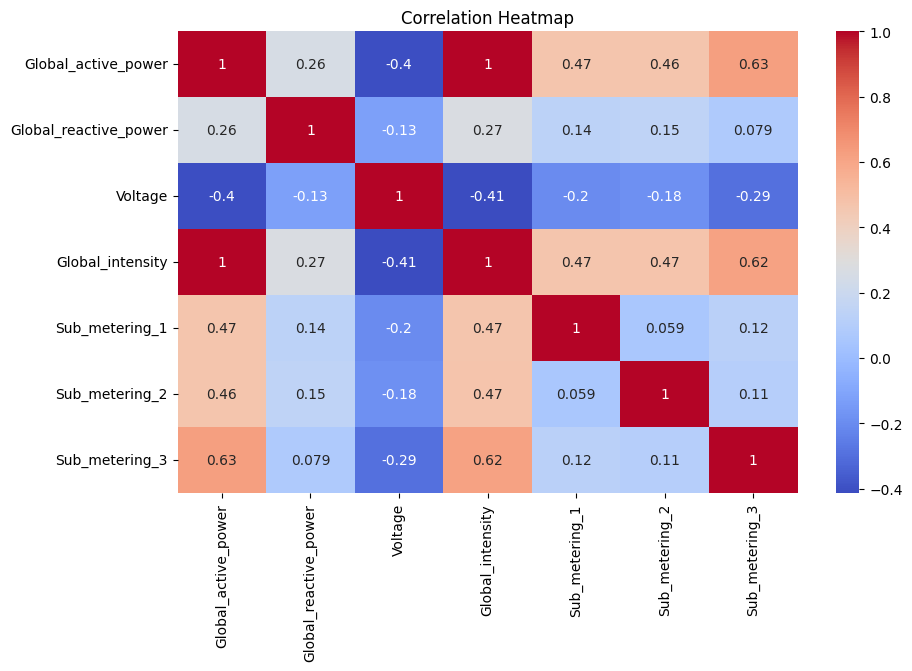

In [54]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# **9. Create Random Forest Model**

In [55]:
model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

print("Model Created!")

Model Created!


# **10. Train Model**

In [56]:
print("Training Started...")

model.fit(
    X_train_scaled,
    y_train
)

print("Model Trained Successfully!")

Training Started...
Model Trained Successfully!


# **11. Predictions**

In [57]:
predictions = model.predict(
    X_test_scaled
)

print("Predictions Generated!")

Predictions Generated!


# **12. Evaluation + Actual vs Predicted Plot**

========== MODEL PERFORMANCE ==========

RMSE     : 0.0397
MAE      : 0.0213
R² Score : 0.9988
MAPE     : 3.47%
Accuracy : 99.88%


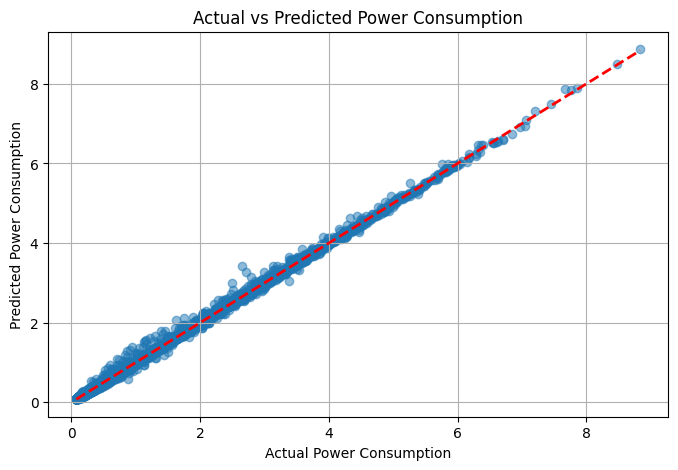

In [58]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

mape = np.mean(
    np.abs(
        (y_test - predictions) / y_test
    )
) * 100

# Accuracy (for regression projects)
accuracy = r2 * 100

print("========== MODEL PERFORMANCE ==========\n")

print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"R² Score : {r2:.4f}")
print(f"MAPE     : {mape:.2f}%")
print(f"Accuracy : {accuracy:.2f}%")

# ------------------------------------------
# ACTUAL VS PREDICTED GRAPH
# ------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title("Actual vs Predicted Power Consumption")
plt.xlabel("Actual Power Consumption")
plt.ylabel("Predicted Power Consumption")

plt.grid(True)

plt.show()

# **13. First 10 Predictions + Save Model**

In [59]:
print("========== FIRST 10 PREDICTIONS ==========\n")

for i in range(10):

    print(
        f"Actual: {y_test.iloc[i]:.4f}"
        f" | Predicted: {predictions[i]:.4f}"
    )

joblib.dump(
    model,
    "first_model.pkl"
)

print("\nModel Saved Successfully!")
print("File Created: first_model.pkl")

========== FIRST 10 PREDICTIONS ==========

Actual: 0.5300 | Predicted: 0.6161
Actual: 0.3280 | Predicted: 0.3159
Actual: 0.2420 | Predicted: 0.2365
Actual: 2.7360 | Predicted: 2.6930
Actual: 1.6900 | Predicted: 1.7178
Actual: 0.3400 | Predicted: 0.3237
Actual: 0.2440 | Predicted: 0.2262
Actual: 1.5920 | Predicted: 1.5826
Actual: 1.5500 | Predicted: 1.5136
Actual: 0.5900 | Predicted: 0.5995

Model Saved Successfully!
File Created: first_model.pkl


# **Why I Chose Random Forest Regressor**

Random Forest Regressor was chosen because the Household Energy Consumption dataset contains multiple numerical features that may have complex and non-linear relationships with the target variable, Global Active Power. Unlike Linear Regression, which assumes a linear relationship between inputs and output, Random Forest can capture more complex patterns in the data.

This algorithm combines predictions from multiple decision trees, making it more accurate
